# Region Topic Analysis

Latent Dirichlet Allocation over regions, to find co-occurring TF binding patterns:

- Running topic modeling with {func}`~tfmindi.tl.run_topic_modeling`
- Choosing a number of topics with {func}`~tfmindi.tl.evaluate_topic_models`
- Visualizing topics in t-SNE space and heatmaps

In [1]:
import tfmindi as tm

# Clustering resolution used in the previous tutorial; it names the annotation column.
res = 5.0
ANNOTATION_COL = f"predicted_{res}_predicted_family_reranked"

/data/groups/vib.ai/stein.aerts/dabaffy/software/conda_envs/tfmindi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Clustered seqlets, saved at the end of tutorial 02
adata = tm.load_h5ad("tutorial_data/seqlets_clustered.h5ad")

## Running topic modeling

{func}`~tfmindi.tl.run_topic_modeling` applies LDA to the seqlet cluster composition of each region.
Every region gets a topic probability distribution, and every topic is a pattern of co-occurring TF
binding clusters. Results land in `adata.uns["topic_modeling"]`.

In [3]:
# Run topic modeling with 15 topics
tm.tl.run_topic_modeling(adata, annotation_col=ANNOTATION_COL, n_topics=15, random_state=42)

Filtered 0 seqlets with unknown annotations
Using 582915 deduplicated seqlets across 38000 regions


2026-08-26 06:07:08 | [INFO] n_documents: 38000
2026-08-26 06:07:08 | [INFO] vocab_size: 67
2026-08-26 06:07:08 | [INFO] n_words: 582915
2026-08-26 06:07:08 | [INFO] n_topics: 15
2026-08-26 06:07:08 | [INFO] n_iter: 150


Count matrix shape: (38000, 67) (regions × clusters)
Fitting LDA model with 15 topics...


2026-08-26 06:07:08 | [INFO] <0> log likelihood: -3968989
2026-08-26 06:07:09 | [INFO] <10> log likelihood: -3872627
2026-08-26 06:07:10 | [INFO] <20> log likelihood: -3695487
2026-08-26 06:07:10 | [INFO] <30> log likelihood: -3366208
2026-08-26 06:07:11 | [INFO] <40> log likelihood: -3167430
2026-08-26 06:07:11 | [INFO] <50> log likelihood: -3001301
2026-08-26 06:07:12 | [INFO] <60> log likelihood: -2874371
2026-08-26 06:07:13 | [INFO] <70> log likelihood: -2785810
2026-08-26 06:07:13 | [INFO] <80> log likelihood: -2728305
2026-08-26 06:07:14 | [INFO] <90> log likelihood: -2690323
2026-08-26 06:07:14 | [INFO] <100> log likelihood: -2666314
2026-08-26 06:07:15 | [INFO] <110> log likelihood: -2642818
2026-08-26 06:07:16 | [INFO] <120> log likelihood: -2624491
2026-08-26 06:07:16 | [INFO] <130> log likelihood: -2617702
2026-08-26 06:07:17 | [INFO] <140> log likelihood: -2604780
2026-08-26 06:07:17 | [INFO] <149> log likelihood: -2601284


Stored topic modeling results in adata.uns['topic_modeling']


## Choosing the number of topics

{func}`~tfmindi.tl.evaluate_topic_models` trains a model per topic count and reports log likelihoods.
The best one is stored in `adata.uns`, overwriting any existing model.

In [4]:
# Evaluate topic models with different numbers of topics
topic_range = [5, 20, 30, 50, 80, 100]
results = tm.tl.evaluate_topic_models(adata, topic_range, annotation_col=ANNOTATION_COL, random_state=42)

Evaluating 6 different topic models...
Training model with 5 topics...
Filtered 0 seqlets with unknown annotations
Using 582915 deduplicated seqlets across 38000 regions


2026-08-26 06:07:19 | [INFO] n_documents: 38000
2026-08-26 06:07:19 | [INFO] vocab_size: 67
2026-08-26 06:07:19 | [INFO] n_words: 582915
2026-08-26 06:07:19 | [INFO] n_topics: 5
2026-08-26 06:07:19 | [INFO] n_iter: 150


Count matrix shape: (38000, 67) (regions × clusters)
Fitting LDA model with 5 topics...


2026-08-26 06:07:20 | [INFO] <0> log likelihood: -3285406
2026-08-26 06:07:20 | [INFO] <10> log likelihood: -3256603
2026-08-26 06:07:20 | [INFO] <20> log likelihood: -3193644
2026-08-26 06:07:21 | [INFO] <30> log likelihood: -3043247
2026-08-26 06:07:21 | [INFO] <40> log likelihood: -2836539
2026-08-26 06:07:21 | [INFO] <50> log likelihood: -2690390
2026-08-26 06:07:22 | [INFO] <60> log likelihood: -2604658
2026-08-26 06:07:22 | [INFO] <70> log likelihood: -2547094
2026-08-26 06:07:22 | [INFO] <80> log likelihood: -2507581
2026-08-26 06:07:23 | [INFO] <90> log likelihood: -2483916
2026-08-26 06:07:23 | [INFO] <100> log likelihood: -2466680
2026-08-26 06:07:23 | [INFO] <110> log likelihood: -2456790
2026-08-26 06:07:23 | [INFO] <120> log likelihood: -2450832
2026-08-26 06:07:24 | [INFO] <130> log likelihood: -2445967
2026-08-26 06:07:24 | [INFO] <140> log likelihood: -2442705
2026-08-26 06:07:24 | [INFO] <149> log likelihood: -2439367


Stored topic modeling results in adata.uns['topic_modeling']
Model with 5 topics: log-likelihood = -2840671.24
Training model with 20 topics...
Filtered 0 seqlets with unknown annotations
Using 582915 deduplicated seqlets across 38000 regions


...

Stored topic modeling results in adata.uns['topic_modeling']
Model with 80 topics: log-likelihood = -4096613.30
Training model with 100 topics...
Filtered 0 seqlets with unknown annotations
Using 582915 deduplicated seqlets across 38000 regions


2026-08-26 06:08:56 | [INFO] n_documents: 38000
2026-08-26 06:08:56 | [INFO] vocab_size: 67
2026-08-26 06:08:56 | [INFO] n_words: 582915
2026-08-26 06:08:56 | [INFO] n_topics: 100
2026-08-26 06:08:56 | [INFO] n_iter: 150


Count matrix shape: (38000, 67) (regions × clusters)
Fitting LDA model with 100 topics...


2026-08-26 06:08:56 | [INFO] <0> log likelihood: -5128946
2026-08-26 06:08:59 | [INFO] <10> log likelihood: -4787662
2026-08-26 06:09:02 | [INFO] <20> log likelihood: -4341566
2026-08-26 06:09:04 | [INFO] <30> log likelihood: -3989992
2026-08-26 06:09:07 | [INFO] <40> log likelihood: -3755089
2026-08-26 06:09:10 | [INFO] <50> log likelihood: -3596258
2026-08-26 06:09:12 | [INFO] <60> log likelihood: -3496275
2026-08-26 06:09:15 | [INFO] <70> log likelihood: -3422524
2026-08-26 06:09:17 | [INFO] <80> log likelihood: -3378300
2026-08-26 06:09:20 | [INFO] <90> log likelihood: -3345994
2026-08-26 06:09:23 | [INFO] <100> log likelihood: -3316663
2026-08-26 06:09:25 | [INFO] <110> log likelihood: -3298383
2026-08-26 06:09:28 | [INFO] <120> log likelihood: -3283614
2026-08-26 06:09:30 | [INFO] <130> log likelihood: -3267500
2026-08-26 06:09:33 | [INFO] <140> log likelihood: -3259634
2026-08-26 06:09:35 | [INFO] <149> log likelihood: -3253515


Stored topic modeling results in adata.uns['topic_modeling']
Model with 100 topics: log-likelihood = -5195223.02
Storing best model with 30 topics...


In [5]:
# find n topics with highest log likelihood
best_n = max(results, key=results.get)
print(f"Best number of topics: {best_n} with log likelihood {results[best_n]}")

Best number of topics: 30 with log likelihood -2676931.5212640655


Topic modeling gives a probability per region per topic:

In [6]:
adata.uns["topic_modeling"]["region_topic_matrix"].head()

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10,...,Topic_21,Topic_22,Topic_23,Topic_24,Topic_25,Topic_26,Topic_27,Topic_28,Topic_29,Topic_30
0,0.028736,0.028736,0.028736,0.028736,0.080460,0.028736,0.028736,0.028736,0.028736,0.063218,...,0.028736,0.028736,0.028736,0.028736,0.028736,0.028736,0.028736,0.028736,0.028736,0.028736
1,0.026455,0.026455,0.026455,0.074074,0.105820,0.026455,0.026455,0.026455,0.026455,0.026455,...,0.026455,0.042328,0.026455,0.026455,0.026455,0.026455,0.026455,0.026455,0.026455,0.026455
2,0.045977,0.028736,0.028736,0.028736,0.028736,0.045977,0.028736,0.028736,0.028736,0.028736,...,0.028736,0.028736,0.028736,0.045977,0.028736,0.028736,0.028736,0.028736,0.028736,0.028736
3,0.038647,0.038647,0.024155,0.053140,0.024155,0.038647,0.024155,0.024155,0.024155,0.024155,...,0.038647,0.024155,0.067633,0.024155,0.024155,0.024155,0.024155,0.067633,0.024155,0.024155
4,0.025641,0.041026,0.025641,0.041026,0.056410,0.025641,0.025641,0.025641,0.025641,0.025641,...,0.025641,0.056410,0.025641,0.025641,0.025641,0.025641,0.041026,0.025641,0.041026,0.025641


## Visualizing topics

### DBD-topic heatmap

{func}`~tfmindi.pl.dbd_topic_heatmap` shows which DNA-binding domains co-occur within a topic.

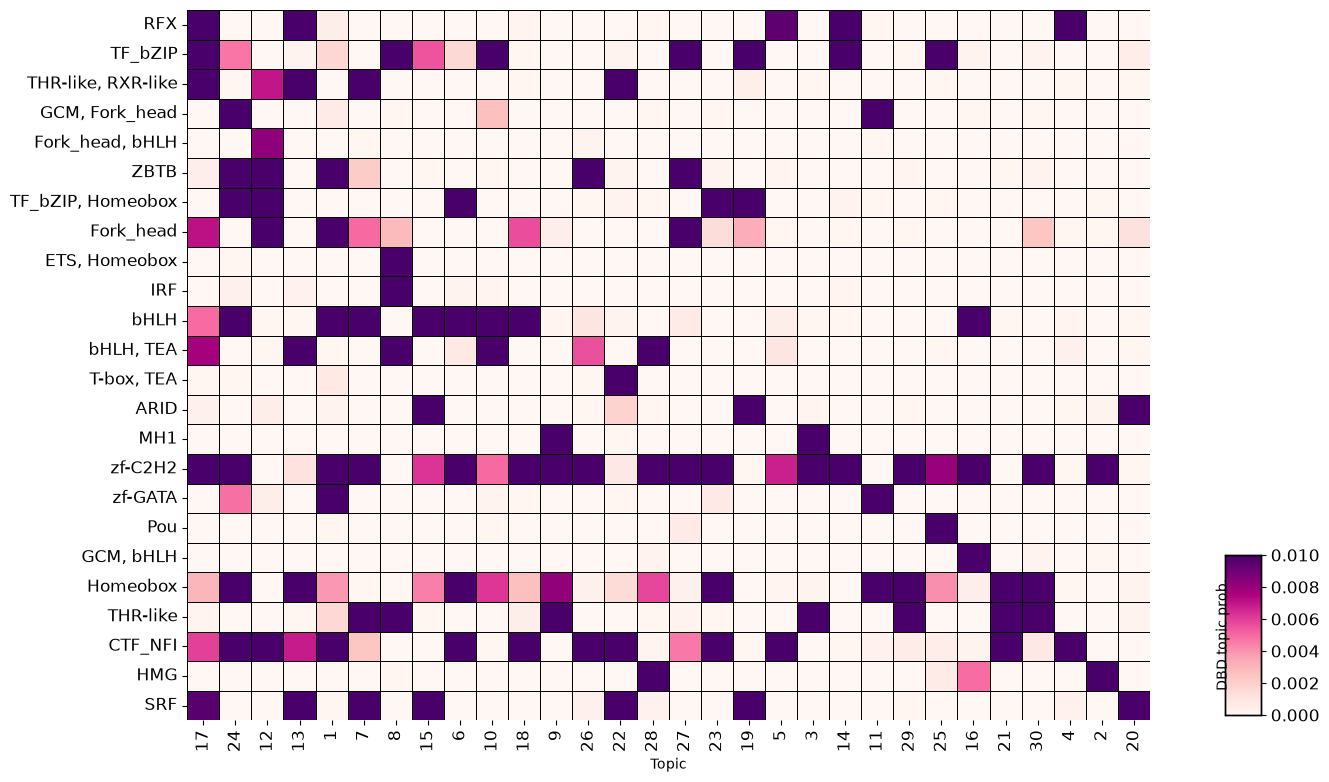

In [7]:
%matplotlib inline
tm.pl.dbd_topic_heatmap(
    adata,
    annotation_col=ANNOTATION_COL,
    width=12,
    height=8,
    x_label_rotation=90,
)

### Topic Visualization in t-SNE Space

Plot t-SNE visualization of regions colored by topic probabilities using {func}`~tfmindi.pl.region_topic_tsne`.

Computing t-SNE coordinates from region-topic matrix...
[2026-08-26 06:09:36.703] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


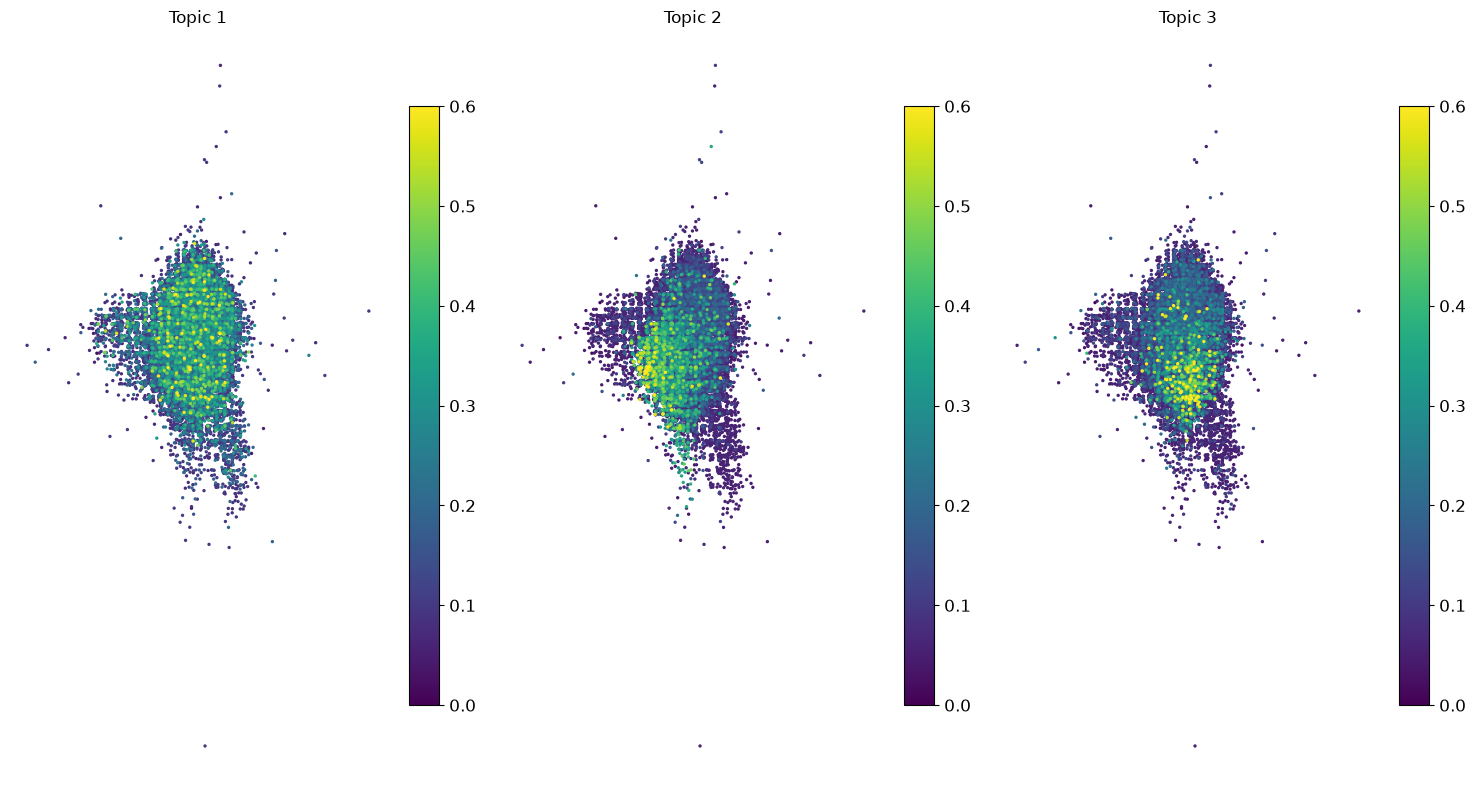

In [8]:
# Plot regions colored by dominant topic
tm.pl.region_topic_tsne(adata, topics_to_show=["Topic_1", "Topic_2", "Topic_3"], ncols=3, width=15)